# Plots
> Draw charts from vectors, matrices and tables

In [ ]:
]help •plot

`X •plot Y` returns a plot spec: a keyed vector holding the data `Y`, the settings `X` and a renderer. Notebooks display the spec as an SVG chart. Plain text on the left is shorthand for `mark`.

The structure of `Y` chooses the series and axes:

- A vector plots its values against `1…n`.
- A keyed vector of numbers uses its keys as x labels.
- A matrix plots one series per row. Row keys name the series. Column keys label x.
- A table, a keyed vector of equal-length columns, plots each column as a series. A column named `x` supplies the x values.
- A vector or matrix of plots draws a figure.

| Setting | Holds | Default |
|---|---|---|
| `mark` | `'line'`, `'point'` or `'bar'` | `'line'` |
| `title` | Chart title | none |
| `width`, `height` | Size in pixels | `600`, `400` |
| `x`, `y` | `title`, `scale` (`'linear'` or `'log'`) and `ticks` | |
| `legend` | `position` (`'end'` or a corner) and `border` | none |
| `grid` | `0` hides the grid lines | `1` |
| `flip` | `1` swaps the axes | `0` |
| `color`, `size`, `labels` | Styles for every series | |
| `series` | Styles for one series, keyed by its name | |
| `widths`, `heights`, `share` | Figure cell sizes and shared axis ranges | |

`•mime` reports these errors: DOMAIN for unknown settings or values; LENGTH when series, sizes or labels don't match the x values; RANK for data that isn't a vector, matrix or table.

## Data

A matrix plots one series per row. Its column keys label the x axis. `'legend':'end'` names each line beside its last point:

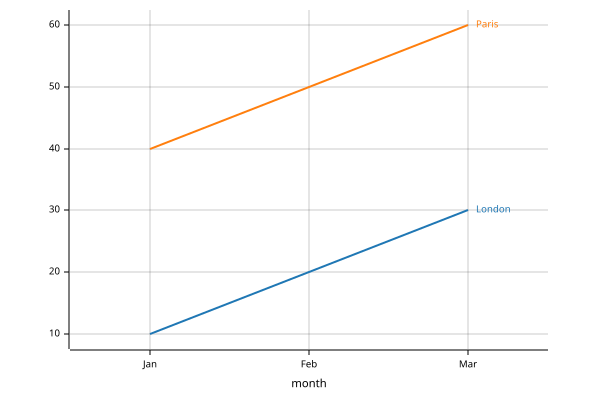

In [ ]:
sales←('city':'London' 'Paris' ⋄ 'month':'Jan' 'Feb' 'Mar'):[10 20 30 ⋄ 40 50 60]
('legend':'end') •plot sales

A keyed vector of numbers uses its keys as x labels:

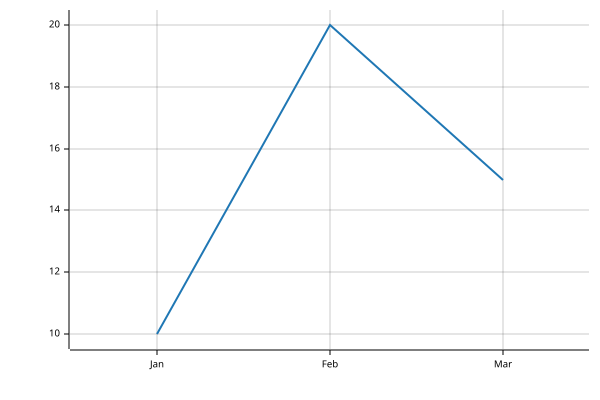

In [ ]:
•plot ('Jan':10 ⋄ 'Feb':20 ⋄ 'Mar':15)

In a table, a column named `x` supplies the x values. Every other column is a series:

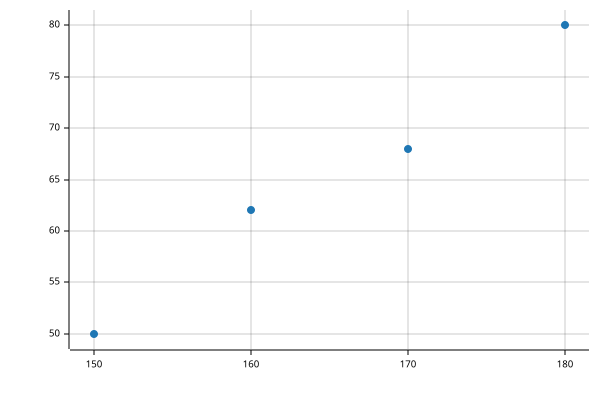

In [ ]:
('mark':'point') •plot ('x':150 160 170 180 ⋄ 'weight':50 62 68 80)

## Settings

The result is a plot spec, an ordinary keyed vector. Settings go on the left, or are assigned later. Assignment through a dot path creates the settings it needs. A corner position draws a boxed legend, titled by the row axis name:

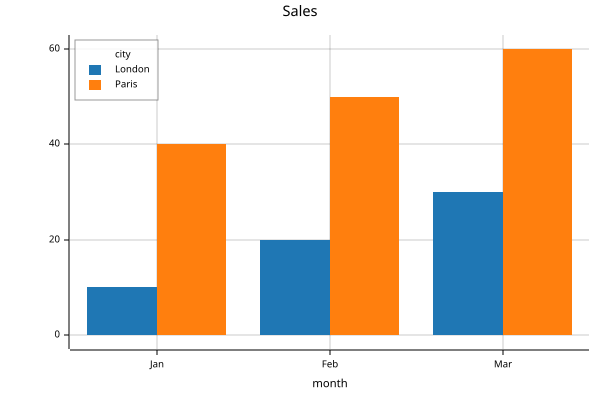

In [ ]:
p←('mark':'bar' ⋄ 'title':'Sales') •plot sales
p.legend.position←'top-left'
p

A `'log'` scale suits values that grow by factors:

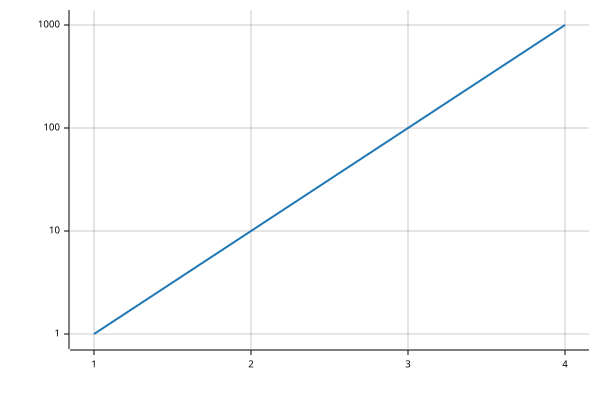

In [ ]:
q←•plot 1 10 100 1000
q.y.scale←'log'
q

`ticks` is a number of ticks, a vector of positions, or a keyed vector from labels to positions:

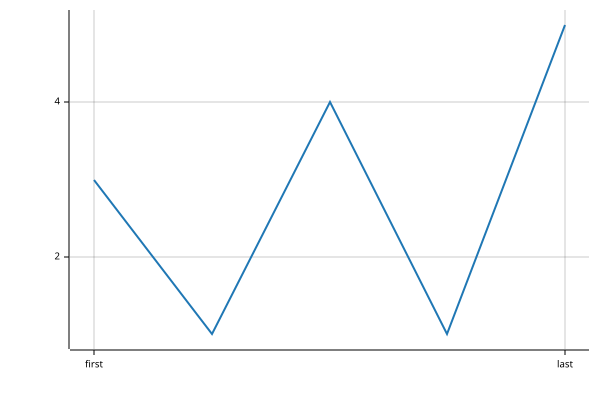

In [ ]:
r←•plot 3 1 4 1 5
r.x.ticks←('first':1 ⋄ 'last':5)
r.y.ticks←3
r

## Series styles

`mark`, `color`, `size` and `labels` style every series. The same fields under `series`, keyed by series name, style one series.

- `color` is `'#rrggbb'` or a palette name: `'blue'`, `'orange'`, `'green'`, `'red'`, `'purple'`, `'brown'`, `'pink'`, `'gray'`, `'olive'` or `'cyan'`. Series take the palette colours in order.
- `size` is the point radius or line width in pixels. For points, one number per point sets sizes by value.
- `labels` is `1` to label each point with its value, or one label per point. `''` leaves a point unlabelled. Overlapping labels move apart.

Computation stays in APL. Here the trend line is a least-squares fit, drawn as a second series:

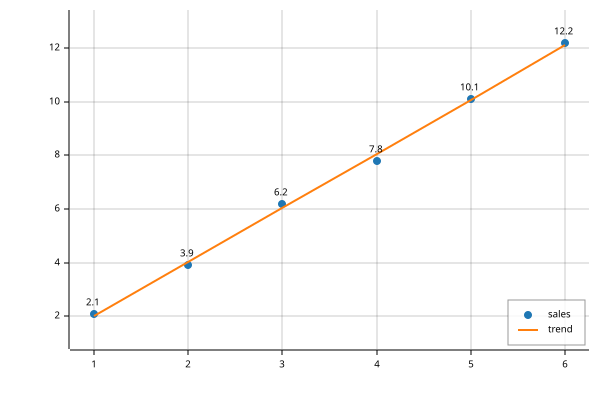

In [ ]:
x←1 2 3 4 5 6 ⋄ y←2.1 3.9 6.2 7.8 10.1 12.2
m←x*⌝0 1
fitted←('mark':'point') •plot ('x':x ⋄ 'sales':y ⋄ 'trend':m+.×y⌹m)
fitted.series.trend.mark←'line'
fitted.series.sales.labels←1
fitted.legend.position←'bottom-right'
fitted

## Figures

A vector or matrix of plots draws a figure. A vector is one row, and `⍪` makes a column. A plot repeated in adjacent cells spans them. `widths` and `heights` give relative cell sizes. `'share':1` gives plots in a column one x range, and plots in a row one y range:

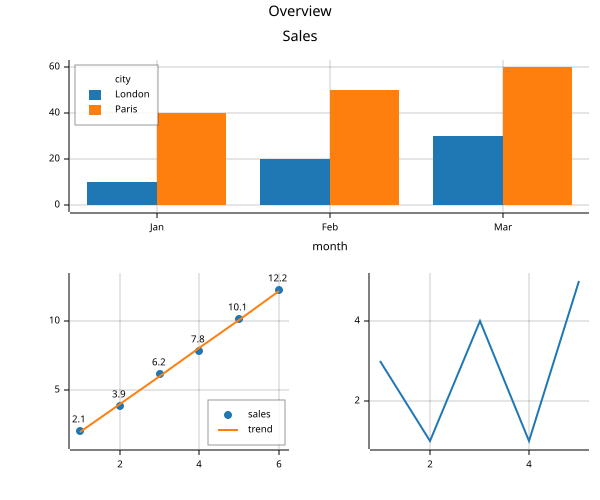

In [ ]:
('title':'Overview' ⋄ 'height':500) •plot [p p ⋄ fitted (•plot 3 1 4 1 5)]

The figure settings combine into a scatter plot with marginal histograms. The data comes from a normal distribution's `quantile` at evenly spread probabilities. That gives normally distributed values without randomness:

In [ ]:
n←•normal 0 1
x←n.quantile 1|0.5+0.618034×⍳400
y←(0.6×x)+0.8×n.quantile 1|0.5+0.754878×⍳400

Binning stays in APL. `count` counts the values within 0.25 of each bin centre. Each histogram is a bar chart of counts. `flip` turns the second one on its side:

In [ ]:
centers←¯2.75+0.5×¯1+⍳12
count←{+/(⍵≥⍺-0.25)∧⍵<⍺+0.25}
top←('mark':'bar') •plot ('x':centers ⋄ 'count':centers count¨⊂x)
side←('mark':'bar' ⋄ 'flip':1) •plot ('x':centers ⋄ 'count':centers count¨⊂y)

`widths` and `heights` make the histograms narrow, and `⍬` leaves the corner empty. `share` lines up each histogram with the scatter plot's axis:

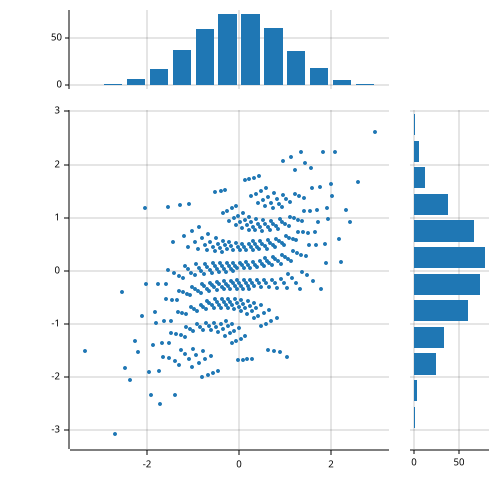

In [ ]:
scatter←('mark':'point' ⋄ 'size':2) •plot ('x':x ⋄ 'y':y)
('widths':4 1 ⋄ 'heights':1 4 ⋄ 'share':1 ⋄ 'width':500 ⋄ 'height':500) •plot [top ⍬ ⋄ scatter side]